In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


In [2]:
TRAIN_DIR = r"E:\ec300\Oral cancer Dataset 2.0\train"
VALID_DIR = r"E:\ec300\Oral cancer Dataset 2.0\valid"

IMG_SIZE = 128
CLASSES = ["cancer", "normal"]

In [3]:
def resize_with_padding(image, target_size=128):
    h, w = image.shape[:2]

    scale = target_size / max(h, w)
    new_h = int(h * scale)
    new_w = int(w * scale)

    resized = cv2.resize(image, (new_w, new_h))

    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)

    y_offset = (target_size - new_h) // 2
    x_offset = (target_size - new_w) // 2

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    return canvas


In [6]:
def load_data(directory):
    data = []
    labels = []

    for label, category in enumerate(CLASSES):
        path = os.path.join(directory, category)

        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)

            # Read image
            image = cv2.imread(img_path)

            # Skip if image not loaded
            if image is None:
                print("Skipped:", img_path)
                continue

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = resize_with_padding(image, IMG_SIZE)
            image = image / 255.0

            data.append(image)
            labels.append(label)

    return np.array(data), np.array(labels)


In [7]:
X_train, y_train = load_data(TRAIN_DIR)
X_val, y_val = load_data(VALID_DIR)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))


Skipped: E:\ec300\Oral cancer Dataset 2.0\train\cancer\101.jpeg
Skipped: E:\ec300\Oral cancer Dataset 2.0\train\cancer\200.jpeg
Skipped: E:\ec300\Oral cancer Dataset 2.0\train\cancer\273.jpeg
Skipped: E:\ec300\Oral cancer Dataset 2.0\train\cancer\317.jpeg
Skipped: E:\ec300\Oral cancer Dataset 2.0\train\cancer\328.jpeg
Skipped: E:\ec300\Oral cancer Dataset 2.0\valid\cancer\407.jpeg
Skipped: E:\ec300\Oral cancer Dataset 2.0\valid\cancer\450.jpeg
Skipped: E:\ec300\Oral cancer Dataset 2.0\valid\cancer\455.jpeg
Skipped: E:\ec300\Oral cancer Dataset 2.0\valid\cancer\481.jpeg
Skipped: E:\ec300\Oral cancer Dataset 2.0\valid\cancer\485.jpeg
Training samples: 645
Validation samples: 295


In [11]:
model = models.Sequential()

model.add(layers.Input(shape=(128,128,3)))

# C1
model.add(layers.Conv2D(6, (5,5), activation='relu'))
model.add(layers.AveragePooling2D(pool_size=(2,2)))

# C2
model.add(layers.Conv2D(16, (5,5), activation='relu'))
model.add(layers.AveragePooling2D(pool_size=(2,2)))

# Flatten
model.add(layers.Flatten())

# Fully Connected
model.add(layers.Dense(120, activation='relu'))
model.add(layers.Dense(84, activation='relu'))

# Output
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 124, 124, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 62, 62, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 58, 58, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 29, 29, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 13456)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │     1,614,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,627,961 (6.21 MB)

 Trainable params: 1,627,961 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val)
)


Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.5302 - loss: 0.7276 - val_accuracy: 0.8203 - val_loss: 0.6302
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.6636 - loss: 0.6180 - val_accuracy: 0.7831 - val_loss: 0.4870
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7550 - loss: 0.5027 - val_accuracy: 0.7593 - val_loss: 0.5301
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8140 - loss: 0.4025 - val_accuracy: 0.6915 - val_loss: 0.6216
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8357 - loss: 0.3467 - val_accuracy: 0.6881 - val_loss: 0.6544
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8946 - loss: 0.2542 - val_accuracy: 0.6780 - val_loss: 0.6940
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9225 - loss: 0.1765 - val_accuracy: 0.7119 - val_loss: 0.7604
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9705 - loss: 0.1083 - val_accuracy: 0.7525 - v

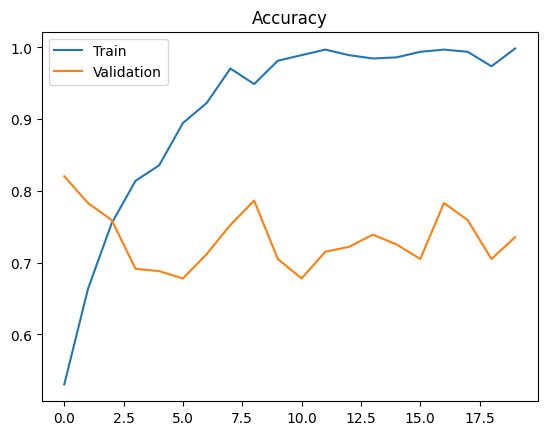

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


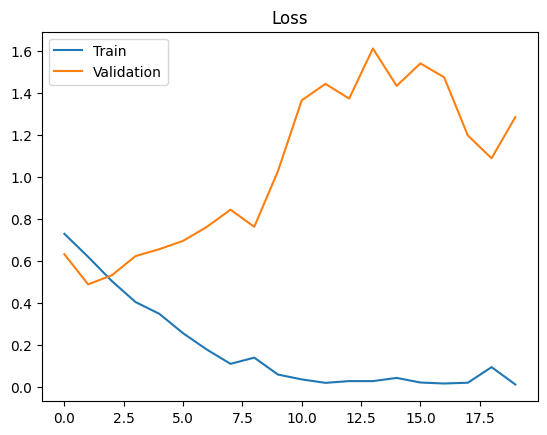

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()
